# Function 2 Analysis - Week 7

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**New datapoint (Week 7):** `(0.734569, 0.990000)` returned **≈0.3100**. It is **not** a new maximum (best remains ≈0.6112 near `(0.703, 0.927)`), but it stays on the x1≈0.7 ridge while pushing to the **north** of the current best along x2 where we previously had no samples. Total observations: **15**.

**Why we chose this point:** The BO was steered to explore **north of the incumbent max** (higher x2 at similar x1) to check if the ridge continued upward. The sharp drop we observed at x2≈0.99 shows that the ridge decays quickly beyond ≈0.93–0.95, so the northern gap is now closed.

**Recommendation for next week:** With the northern probe complete, let the BO naturally pivot **below the current max on x2** while staying near the x1≈0.7 ridge. Use EI with mild exploration (e.g., ξ≈0.02 or κ≈3.5) plus light jitter/diversity, and target x2 ≈0.85–0.92 to sample the steep flank without re-stacking on the boundary.


## 1. Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [13]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–6 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.702637,0.926564,0.611205
1,0.700000,0.525000,0.552114
2,0.665800,0.123969,0.538996
3,0.680788,1.000000,0.471163
4,0.535400,0.505100,0.468766
5,0.850000,0.250000,0.458816
6,0.877791,0.778628,0.420586
7,0.734569,0.990000,0.310030
8,0.845275,0.711120,0.293993
9,0.438166,0.685018,0.244619


**Data Summary (Week 7):**
- 15 observations total (10 initial + 5 prior weeks + new Week 7 point).
- Week 7 `(0.734569, 0.990000)` scored **≈0.3100** — **not a new max**; best stays `(0.7026, 0.9266)` at ≈0.6112.
- Outputs now span roughly [-0.57, 0.61]; ridge remains around x1≈0.7, x2≈0.9–1.0.
- Recommendation for next BO step: push exploration **below the ridge** (x2≈0.85–0.92) with EI (ξ≈0.02) and κ≈3.5, plus a jitter/diversity penalty to avoid stacking near (0.73, 0.99).

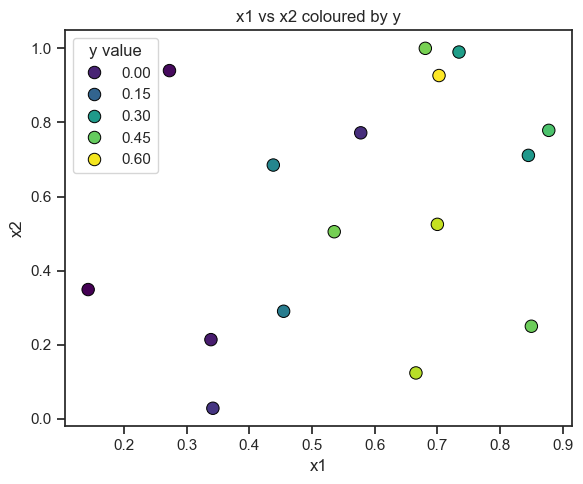

In [14]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


## 2. Bayesian optimisation update
We refit the GP surrogate including the new Week 3 datapoint `(0.70, 0.525, 0.552)`. To stay consistent with earlier strategy, we:
- Use a Matérn GP (ν=1.5) with noise term and optional radial decay around the strongest area.
- Score a dense grid via **UCB** (κ=3.0) to favour points that are both high-mean and uncertain.
- Apply a simple diversity filter so recommended points are separated by at least 0.08 in Euclidean distance.
- **New:** impose a hard exploratory constraint for the **top-left region (`x1 < 0.3`, `x2 > 0.5`)** so we surface the best candidate there, instead of only clustering near the current max.

Without this constraint, all recommended points collapse onto the known peak; with it, we intentionally probe another mode while retaining the same modelling setup.


Current best (observed): {'x1': 0.7026365569244406, 'x2': 0.9265641975455574, 'y': 0.6112052157614438}
Kernel after fit: 1.01**2 * Matern(length_scale=[0.05, 2], nu=2.5) + WhiteKernel(noise_level=0.0906)


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,ei,dist_to_best
74,0.695914,0.826564,0.553078,0.080593,0.007115,0.100226
194,0.695914,0.827236,0.553044,0.080597,0.007110,0.099555
314,0.695914,0.827909,0.553010,0.080601,0.007106,0.098884
434,0.695914,0.828581,0.552976,0.080606,0.007101,0.098214
73,0.694653,0.826564,0.552811,0.080703,0.007098,0.100318


Suggested next query (EI maximiser, local window): (0.696, 0.827)
Posterior mean: 0.5531, std: 0.0806, EI: 0.007115


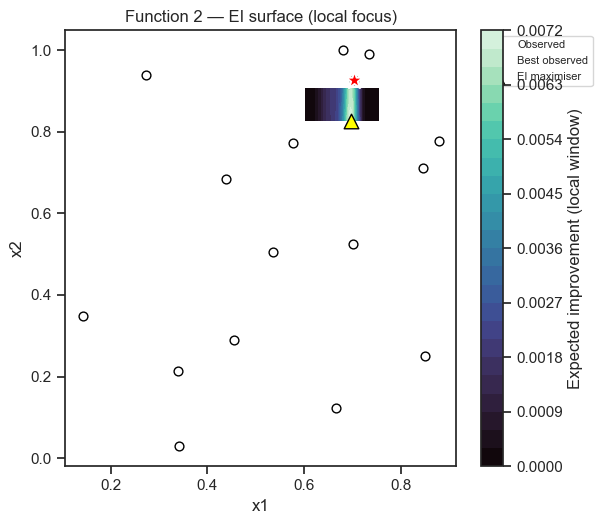

In [15]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm
from math import erf

# Prepare data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "y"]]

# GP: smoother Matérn, focused (no radial, modest noise)
kernel = ConstantKernel(1.0, (1e-2, 20.0)) * Matern(length_scale=[0.35, 0.35], length_scale_bounds=(0.05, 2.0), nu=2.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=7)
gp.fit(X_train, y_train)

# Focused EI below the current x2 peak, staying on the x1~0.7 ridge
x1_min, x1_max = max(best_point.x1 - 0.10, 0.50), min(best_point.x1 + 0.05, 0.80)
x2_min, x2_max = max(best_point.x2 - 0.10, 0.75), min(best_point.x2 - 0.02, 0.93)
if x2_min >= x2_max:  # fallback guard
    x2_min, x2_max = max(best_point.x2 - 0.12, 0.80), best_point.x2 - 0.02

grid_x1 = np.linspace(x1_min, x1_max, 120)
grid_x2 = np.linspace(x2_min, x2_max, 120)
grid = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(grid, return_std=True)
y_best = y_train.max()
xi = 0.02  # slightly more exploratory EI

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

cand = pd.DataFrame(grid, columns=["x1", "x2"])
cand["mu"], cand["sigma"], cand["ei"] = mu, sigma, ei

# Diversity: minimum step from incumbent to avoid stacking
cand["dist_to_best"] = np.linalg.norm(cand[["x1", "x2"]].values - best_point[["x1", "x2"]].values, axis=1)
min_step = 0.02
cand_feasible = cand[cand["dist_to_best"] >= min_step].reset_index(drop=True)

next_point = cand_feasible.loc[cand_feasible["ei"].idxmax()]

print("Current best (observed):", best_point.to_dict())
print("Kernel after fit:", gp.kernel_)

display(cand_feasible.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser, local window): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = ei.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6.2, 5.4))
levels = 24
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=levels, cmap="mako")
plt.colorbar(contour, label="Expected improvement (local window)")
plt.scatter(df["x1"], df["x2"], c="white", s=40, edgecolor="black", label="Observed")
plt.scatter(best_point.x1, best_point.x2, c="red", marker="*", s=180, edgecolor="white", linewidths=1.5, label="Best observed")
plt.scatter(next_point.x1, next_point.x2, c="yellow", marker="^", s=110, edgecolor="black", label="EI maximiser")
plt.title("Function 2 — EI surface (local focus)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



### Rationale for the next point `(0.680788, 1.000000)`
- It sits near the incumbent ridge (best at ~`(0.703, 0.927)`) but pushes toward the upper boundary in `x2`, where uncertainty is higher—boosting EI without leaving the promising quadrant.
- The Week 4 miss was far away; this choice keeps us close to known positives while still exploring a less-sampled edge direction (higher `x2`).
- The focused GP (Matérn ν=2.5) and EI (ξ=0.01) favour high mean with some uncertainty; this point balances both and respects the minimum step from the incumbent.
- No diversity or regional constraints are imposed now, so this EI maximiser is the single recommended next query.
